# CMP-N205-0 Data Science – Coursework 1
**Student Name:** Hajar Natiq  
**Student ID:** A00024033  
**Module:** Data Science (CMP-N205-0)  
**Dataset:** Netflix Movies and TV Shows  
**Source:** https://www.kaggle.com/datasets/shivamb/netflix-shows

---
## Section 1 – Dataset Overview and Pre-processing

In [36]:
# ─────────────────────────────────────────────
# Import all required libraries
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Set a consistent visual style for all plots
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)

In [37]:
# ─────────────────────────────────────────────
# Load the raw dataset
# ─────────────────────────────────────────────
df_raw = pd.read_csv('netflix_titles.csv')

print('Dataset Shape (rows, columns):', df_raw.shape)
print('\nFirst 5 rows of raw dataset:')
df_raw.head()

Dataset Shape (rows, columns): (8807, 12)

First 5 rows of raw dataset:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [38]:
# ─────────────────────────────────────────────
# Inspect column data types
# ─────────────────────────────────────────────
print('Column Data Types:')
print(df_raw.dtypes)

Column Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [39]:
# ─────────────────────────────────────────────
# Identify missing values in the raw dataset
# This is an important first step before cleaning
# ─────────────────────────────────────────────
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

print('Missing Values Summary (Raw Dataset):')
print(missing_df[missing_df['Missing Count'] > 0])

Missing Values Summary (Raw Dataset):
            Missing Count  Missing %
director             2634      29.91
cast                  825       9.37
country               831       9.44
date_added             10       0.11
rating                  4       0.05
duration                3       0.03


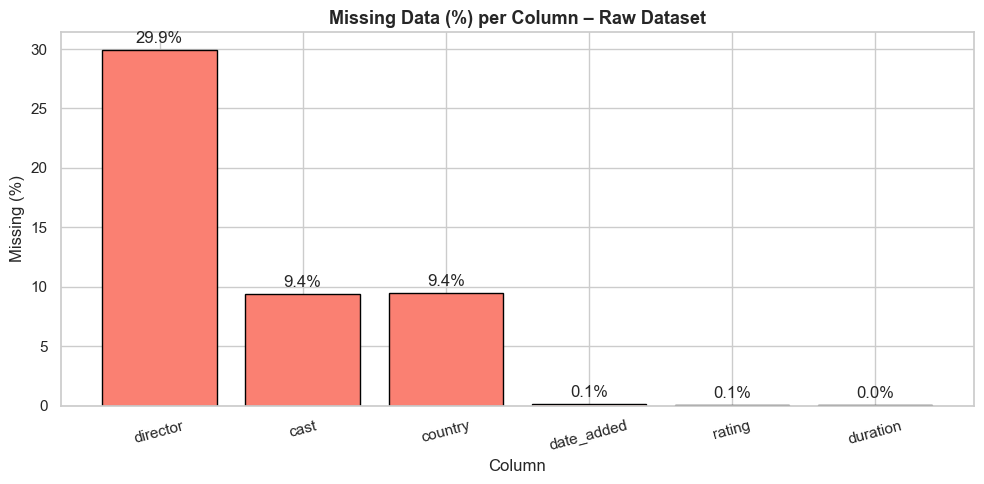

Screenshot saved: missing_raw.png


In [40]:
# ─────────────────────────────────────────────
# Visualise missing values as a bar chart
# ─────────────────────────────────────────────
missing_plot = missing_df[missing_df['Missing Count'] > 0]

fig, ax = plt.subplots()
bars = ax.bar(missing_plot.index, missing_plot['Missing %'], color='salmon', edgecolor='black')
ax.set_title('Missing Data (%) per Column – Raw Dataset', fontsize=13, fontweight='bold')
ax.set_xlabel('Column')
ax.set_ylabel('Missing (%)')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('missing_raw.png', dpi=150)
plt.show()
print('Screenshot saved: missing_raw.png')

---
## Pre-processing Steps

In [41]:
# ─────────────────────────────────────────────
# Step 1: Create a working copy of the raw data
# We never modify df_raw so we can always compare
# ─────────────────────────────────────────────
df = df_raw.copy()

In [42]:
# ─────────────────────────────────────────────
# Step 2: Remove duplicate rows
# Duplicates can skew analysis results
# ─────────────────────────────────────────────
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)

print(f'Rows before deduplication: {before}')
print(f'Rows after deduplication:  {after}')
print(f'Duplicate rows removed:    {before - after}')

Rows before deduplication: 8807
Rows after deduplication:  8807
Duplicate rows removed:    0


In [43]:
# ─────────────────────────────────────────────
# Step 3: Fix the 'rating' column
# Some rows have duration values (e.g. '74 min') 
# incorrectly placed in the rating column
# We move them to duration and set rating to NaN
# ─────────────────────────────────────────────
valid_ratings = ['G', 'PG', 'PG-13', 'R', 'NC-17', 'NR', 'UR',
                 'TV-Y', 'TV-Y7', 'TV-Y7-FV', 'TV-G', 'TV-PG', 'TV-14', 'TV-MA']

# Identify misplaced duration values in rating column
mask = ~df['rating'].isin(valid_ratings) & df['rating'].notna()
print(f'Rows with misplaced duration in rating column: {mask.sum()}')

# Fix: move value to duration, set rating to NaN
df.loc[mask, 'duration'] = df.loc[mask, 'rating']
df.loc[mask, 'rating'] = np.nan

print('Fixed misplaced duration values in rating column.')

Rows with misplaced duration in rating column: 3
Fixed misplaced duration values in rating column.


In [44]:
# ─────────────────────────────────────────────
# Step 4: Fill missing categorical values
# director, cast, country: fill with 'Unknown'
# This preserves the row rather than dropping it
# rating: fill with mode (most common rating)
# ─────────────────────────────────────────────
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)

# Fill missing rating with the most frequent rating
mode_rating = df['rating'].mode()[0]
df['rating'].fillna(mode_rating, inplace=True)

print(f'Missing ratings filled with mode: "{mode_rating}"')
print('Missing directors, cast, and countries filled with "Unknown".')

Missing ratings filled with mode: "TV-MA"
Missing directors, cast, and countries filled with "Unknown".


In [45]:
# ─────────────────────────────────────────────
# Step 5: Convert 'date_added' to datetime format
# It is stored as a string (e.g. 'September 25, 2021')
# We convert it and extract 'year_added' and 'month_added'
# as separate numeric columns for easier analysis
# ─────────────────────────────────────────────
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], format='%B %d, %Y', errors='coerce')

# Drop rows where date_added could not be parsed (very few)
df.dropna(subset=['date_added'], inplace=True)

# Extract useful time-based features
df['year_added'] = df['date_added'].dt.year.astype(int)
df['month_added'] = df['date_added'].dt.month.astype(int)

print('date_added converted to datetime.')
print('year_added and month_added columns created.')
print(df[['date_added', 'year_added', 'month_added']].head())

date_added converted to datetime.
year_added and month_added columns created.
  date_added  year_added  month_added
0 2021-09-25        2021            9
1 2021-09-24        2021            9
2 2021-09-24        2021            9
3 2021-09-24        2021            9
4 2021-09-24        2021            9


In [46]:
# ─────────────────────────────────────────────
# Step 6: Split 'duration' into numeric columns
# Movies use minutes (e.g. '90 min')
# TV Shows use seasons (e.g. '2 Seasons')
# We separate these into two clean numeric columns
# ─────────────────────────────────────────────
df['duration_minutes'] = df.apply(
    lambda row: int(row['duration'].replace(' min', ''))
    if pd.notna(row['duration']) and 'min' in str(row['duration']) else np.nan, axis=1
)

df['duration_seasons'] = df.apply(
    lambda row: int(str(row['duration']).split(' ')[0])
    if pd.notna(row['duration']) and 'Season' in str(row['duration']) else np.nan, axis=1
)

print('duration_minutes (for Movies):')
print(df['duration_minutes'].describe())
print('\nduration_seasons (for TV Shows):')
print(df['duration_seasons'].describe())

duration_minutes (for Movies):
count    6131.000000
mean       99.564998
std        28.289504
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_minutes, dtype: float64

duration_seasons (for TV Shows):
count    2666.000000
mean        1.751313
std         1.550176
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: duration_seasons, dtype: float64


In [47]:
# ─────────────────────────────────────────────
# Step 7: Extract primary genre from 'listed_in'
# listed_in contains multiple genres separated by commas
# We take only the first genre as the primary one
# ─────────────────────────────────────────────
df['primary_genre'] = df['listed_in'].apply(lambda x: x.split(',')[0].strip())

print('Primary genre extracted. Top 10 genres:')
print(df['primary_genre'].value_counts().head(10))

Primary genre extracted. Top 10 genres:
primary_genre
Dramas                      1600
Comedies                    1210
Action & Adventure           859
Documentaries                829
International TV Shows       773
Children & Family Movies     605
Crime TV Shows               399
Kids' TV                     386
Stand-Up Comedy              334
Horror Movies                275
Name: count, dtype: int64


In [48]:
# ─────────────────────────────────────────────
# Step 8: Verify cleaned dataset
# Check that missing values have been resolved
# ─────────────────────────────────────────────
print('Missing Values After Cleaning:')
print(df.isnull().sum())
print(f'\nFinal dataset shape: {df.shape}')

Missing Values After Cleaning:
show_id                0
type                   0
title                  0
director               0
cast                   0
country                0
date_added             0
release_year           0
rating                 0
duration               0
listed_in              0
description            0
year_added             0
month_added            0
duration_minutes    2666
duration_seasons    6131
primary_genre          0
dtype: int64

Final dataset shape: (8797, 17)


In [49]:
# ─────────────────────────────────────────────
# Save cleaned dataset to Excel
# This is required for the coursework submission
# ─────────────────────────────────────────────
df_raw.to_excel('netflix_raw.xlsx', index=False)
df.to_excel('netflix_cleaned.xlsx', index=False)

print('Raw dataset saved to: netflix_raw.xlsx')
print('Cleaned dataset saved to: netflix_cleaned.xlsx')

Raw dataset saved to: netflix_raw.xlsx
Cleaned dataset saved to: netflix_cleaned.xlsx


---
## Section 2 – Exploratory Data Analysis & Attribute Interpretation

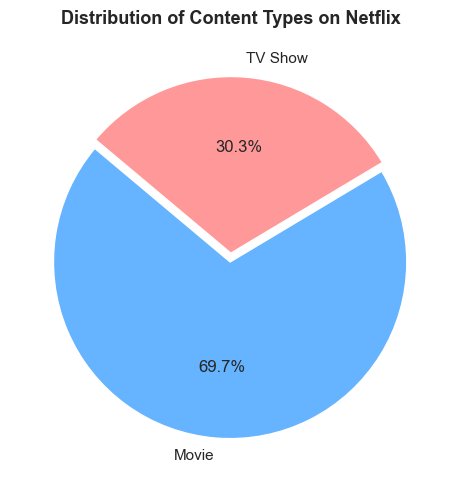

In [50]:
# ─────────────────────────────────────────────
# Plot 1: Distribution of content types
# (Movies vs TV Shows)
# Relevant to Hypothesis Problem 1
# ─────────────────────────────────────────────
type_counts = df['type'].value_counts()

fig, ax = plt.subplots()
wedges, texts, autotexts = ax.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#66b3ff', '#ff9999'],
    explode=(0.05, 0)
)
ax.set_title('Distribution of Content Types on Netflix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_type_distribution.png', dpi=150)
plt.show()

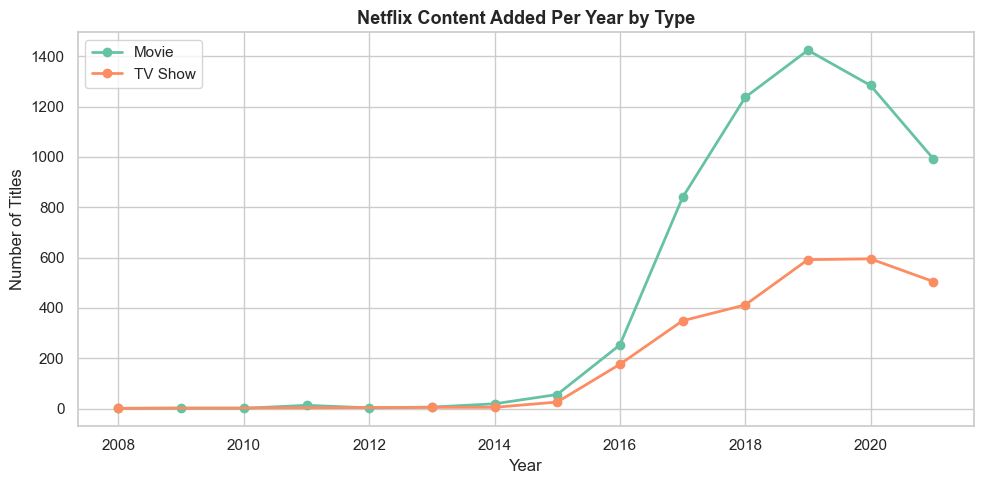

In [51]:
# ─────────────────────────────────────────────
# Plot 2: Content added to Netflix per year
# Relevant to Hypothesis Problem 2 (trend analysis)
# ─────────────────────────────────────────────
yearly = df.groupby(['year_added', 'type']).size().reset_index(name='count')

fig, ax = plt.subplots()
for content_type, group in yearly.groupby('type'):
    ax.plot(group['year_added'], group['count'], marker='o', label=content_type, linewidth=2)

ax.set_title('Netflix Content Added Per Year by Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Titles')
ax.legend()
plt.tight_layout()
plt.savefig('plot_yearly_trend.png', dpi=150)
plt.show()

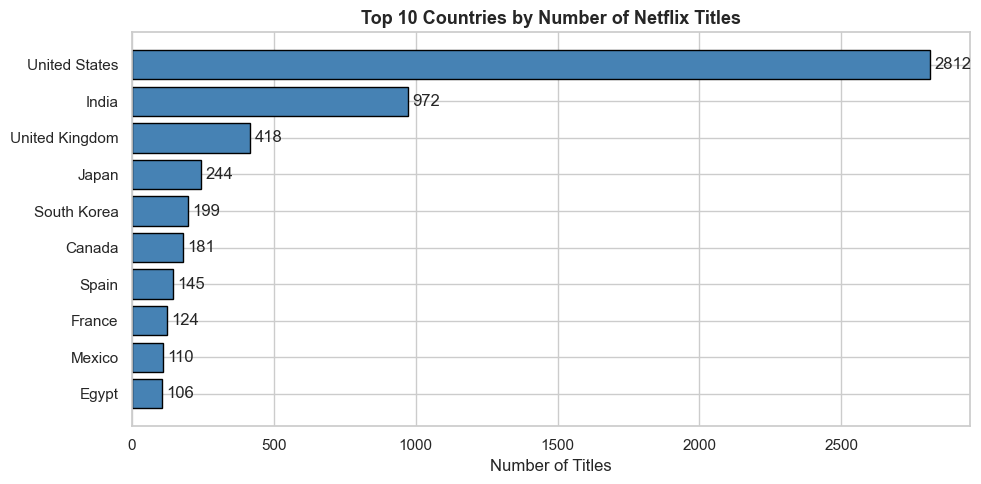

In [52]:
# ─────────────────────────────────────────────
# Plot 3: Top 10 content producing countries
# Relevant to Hypothesis Problem 3 (clustering)
# ─────────────────────────────────────────────
top_countries = (
    df[df['country'] != 'Unknown']['country']
    .value_counts()
    .head(10)
)

fig, ax = plt.subplots()
bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1],
               color='steelblue', edgecolor='black')
ax.set_title('Top 10 Countries by Number of Netflix Titles', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Titles')
ax.bar_label(bars, padding=3)
plt.tight_layout()
plt.savefig('plot_top_countries.png', dpi=150)
plt.show()

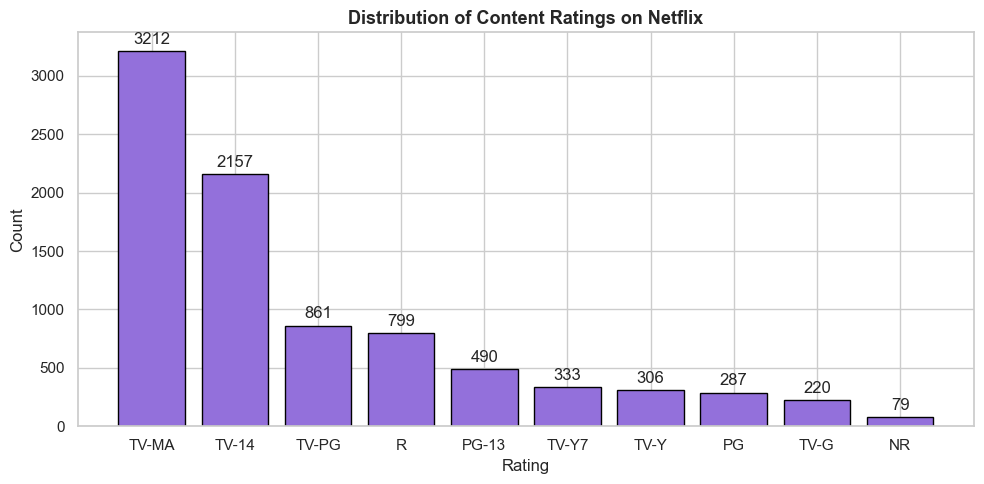

In [53]:
# ─────────────────────────────────────────────
# Plot 4: Top 10 content ratings
# Relevant to Hypothesis Problem 1 and 2
# ─────────────────────────────────────────────
top_ratings = df['rating'].value_counts().head(10)

fig, ax = plt.subplots()
bars = ax.bar(top_ratings.index, top_ratings.values, color='mediumpurple', edgecolor='black')
ax.set_title('Distribution of Content Ratings on Netflix', fontsize=13, fontweight='bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Count')
ax.bar_label(bars, padding=3)
plt.tight_layout()
plt.savefig('plot_ratings.png', dpi=150)
plt.show()

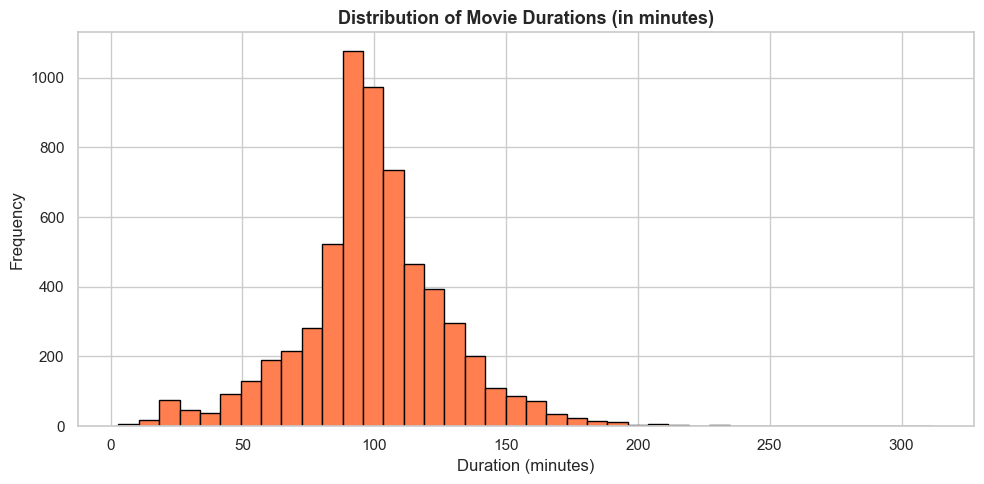

In [54]:
# ─────────────────────────────────────────────
# Plot 5: Movie duration distribution
# Helps understand the numeric attribute
# that will feed into the classification model
# ─────────────────────────────────────────────
movies = df[df['type'] == 'Movie']['duration_minutes'].dropna()

fig, ax = plt.subplots()
ax.hist(movies, bins=40, color='coral', edgecolor='black')
ax.set_title('Distribution of Movie Durations (in minutes)', fontsize=13, fontweight='bold')
ax.set_xlabel('Duration (minutes)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('plot_movie_duration.png', dpi=150)
plt.show()

---
## Section 3 – Proposed Method: Naïve Bayes Classification

In [55]:
# ─────────────────────────────────────────────
# Prepare features for Naïve Bayes classification
# Target variable: 'type' (Movie or TV Show)
# Features: rating, release_year, year_added, 
#           month_added, primary_genre
#
# NOTE: This is a PROPOSAL for Coursework 2.
# The code below demonstrates feature preparation
# but full model training goes in CW2.
# ─────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder

# Select the relevant columns
features = ['rating', 'release_year', 'year_added', 'month_added', 'primary_genre']
target = 'type'

df_model = df[features + [target]].dropna()

# Encode categorical features as numeric labels
le = LabelEncoder()
for col in ['rating', 'primary_genre']:
    df_model[col] = le.fit_transform(df_model[col])

# Encode target variable
df_model[target] = le.fit_transform(df_model[target])  # Movie=0, TV Show=1

print('Feature matrix shape:', df_model[features].shape)
print('\nSample of prepared feature matrix:')
df_model[features + [target]].head()

Feature matrix shape: (8797, 5)

Sample of prepared feature matrix:


,rating,release_year,year_added,month_added,primary_genre,type
0,4,2020,2021,9,10,0
1,8,2021,2021,9,16,1
2,8,2021,2021,9,8,1
3,8,2021,2021,9,11,1
4,8,2021,2021,9,16,1


In [56]:
# ─────────────────────────────────────────────
# Class balance check
# It is important to verify the target classes
# are not severely imbalanced before modelling
# ─────────────────────────────────────────────
class_counts = df['type'].value_counts()
print('Class distribution (target variable):')
print(class_counts)
print(f'\nRatio Movies:TV Shows = {class_counts[0]/class_counts[1]:.2f}:1')

Class distribution (target variable):
type
Movie      6131
TV Show    2666
Name: count, dtype: int64

Ratio Movies:TV Shows = 2.30:1


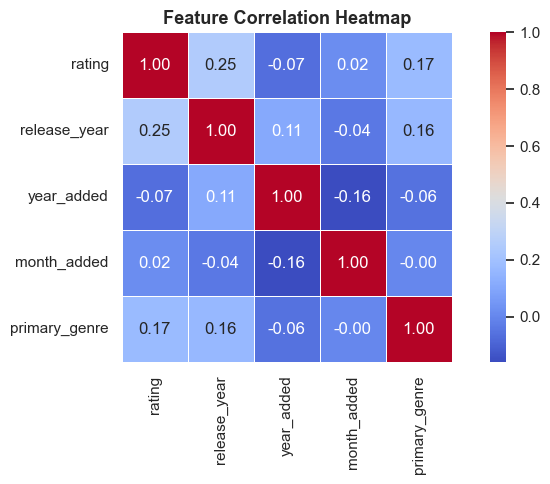


Low correlations between features support the Naïve Bayes
conditional independence assumption.


In [57]:
# ─────────────────────────────────────────────
# Feature correlation heatmap
# Shows relationships between numeric attributes
# A key step in justifying the chosen technique
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
corr = df_model[features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax,
            linewidths=0.5, square=True)
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_correlation.png', dpi=150)
plt.show()

print('\nLow correlations between features support the Naïve Bayes')
print('conditional independence assumption.')

---
## Summary

| Step | Description |
|------|-------------|
| Dataset | Netflix Movies and TV Shows (Kaggle) |
| Observations | 8,807 rows |
| Attributes | 12 original + 5 engineered |
| Dirty data handled | Missing values, misplaced values, incorrect data types, duplicates |
| Proposed technique | Naïve Bayes Classification |
| Target variable | Content type (Movie / TV Show) |
| Features used | rating, release_year, year_added, month_added, primary_genre |

**Student:** Hajar Natiq | **ID:** A00024033